# 0. Импорты и константы


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from pathlib import Path
from IPython.display import display

%matplotlib inline

SEED = 42
np.random.seed(SEED)

PRODUCTS = {
    'Молоко':   {'base_price': 80,  'elasticity': 2.0, 'base_sales': 300},
    'Хлеб':    {'base_price': 50,  'elasticity': 1.5, 'base_sales': 250},
    'Сок':     {'base_price': 120, 'elasticity': 3.0, 'base_sales': 150},
    'Кофе':    {'base_price': 450, 'elasticity': 1.2, 'base_sales': 80},
    'Шоколад': {'base_price': 100, 'elasticity': 2.5, 'base_sales': 200}
}

# --- ФУНКЦИИ ---
def apply_rules(row: pd.Series, avg_sales_7d: float) -> tuple[float, str]:
    """Применяет эвристические правила к последнему дню для определения рекомендуемой цены."""
    our_price = row['our_price']
    competitor_price = row['competitor_price']
    sales = row['sales']
    
    if competitor_price < our_price * 0.90:
        return round(our_price * 0.95, 2), "competitor_undercut"
    elif sales < avg_sales_7d * 0.80:
        return round(our_price - 1.0, 2), "low_sales"
    else:
        return our_price, "hold"

def forecast(product: str, rec_price: float, current_revenue: float) -> tuple[int, float, float]:
    """Прогноз объема продаж и выручки после изменения цены."""
    params = PRODUCTS[product]
    base_price = params['base_price']
    elasticity = params['elasticity']
    base_sales = params['base_sales']
    
    price_dev = rec_price - base_price
    predicted_sales = max(0, round(base_sales - elasticity * price_dev))
    predicted_revenue = predicted_sales * rec_price
    
    delta_pct = 0.0
    if current_revenue > 0:
        delta_pct = (predicted_revenue - current_revenue) / current_revenue * 100
        
    return predicted_sales, predicted_revenue, delta_pct

def simulate(df_history: pd.DataFrame, n_steps: int = 10, method: str = 'regression') -> pd.DataFrame:
    """Симуляция поведения рынка на n_steps дней вперед."""
    sim_df = df_history.copy()
    
    # Предподготовка для регрессии
    reg_results = {}
    if method == 'regression':
        for prod in PRODUCTS:
            sub = sim_df[sim_df['product'] == prod]
            if not sub.empty:
                X = sub['our_price'].values.reshape(-1, 1)
                y = sub['sales'].values
                model = LinearRegression().fit(X, y)
                a = model.intercept_
                b = abs(model.coef_[0])
                optimal_price = round(a / (2 * b), 2)
                reg_results[prod] = optimal_price

    for step in range(n_steps):
        last_date = pd.to_datetime(sim_df['date']).max()
        next_date = last_date + pd.Timedelta(days=1)
        next_date_str = next_date.strftime('%Y-%m-%d')
        
        new_rows = []
        for prod in PRODUCTS:
            prod_hist = sim_df[sim_df['product'] == prod]
            if prod_hist.empty:
                continue
            last_row = prod_hist.iloc[-1]
            
            if method == 'rules':
                avg_sales_7d = prod_hist['sales'].tail(7).mean()
                rec_price, _ = apply_rules(last_row, avg_sales_7d)
            else:
                rec_price = reg_results.get(prod, last_row['our_price'])
                
            params = PRODUCTS[prod]
            price_dev = rec_price - params['base_price']
            new_sales = params['base_sales'] - params['elasticity'] * price_dev + np.random.normal(0, 5)
            new_sales = max(0, round(new_sales))
            new_revenue = new_sales * rec_price
            
            new_row = {
                'date': next_date_str,
                'product_id': last_row.get('product_id', 0),
                'product': prod,
                'our_price': rec_price,
                'competitor_price': last_row['competitor_price'], # оставляем без изменений
                'sales': new_sales,
                'revenue': new_revenue
            }
            new_rows.append(new_row)
            
        sim_df = pd.concat([sim_df, pd.DataFrame(new_rows)], ignore_index=True)
            
    return sim_df


# 1. Загрузка и обзор данных (EDA)


Shape: (500, 7)

Dtypes:
 date                    str
product_id            int64
product                 str
our_price           float64
competitor_price    float64
sales               float64
revenue             float64
dtype: object

Describe:
        product_id   our_price  competitor_price       sales       revenue
count   500.00000  500.000000        500.000000  500.000000    500.000000
mean      3.00000  159.255980        158.883420  197.162000  22197.242320
std       1.41563  146.319611        147.260172   78.103342   9839.713201
min       1.00000   45.010000         39.410000   24.000000  10937.430000
25%       2.00000   76.077500         71.542500  135.000000  16197.105000
50%       3.00000   99.880000         98.535000  200.000000  19906.180000
75%       4.00000  125.477500        130.187500  255.250000  24142.212500
max       5.00000  493.730000        564.840000  323.000000  56005.920000


,date,product_id,product,our_price,competitor_price,sales,revenue
0,2025-12-26,4,Кофе,437.16,405.73,98.0,42841.68
1,2025-12-26,1,Молоко,81.90,87.71,301.0,24651.90
2,2025-12-26,3,Сок,115.77,133.07,167.0,19333.59
3,2025-12-26,2,Хлеб,52.48,59.78,251.0,13172.48
4,2025-12-26,5,Шоколад,99.97,95.05,207.0,20693.79


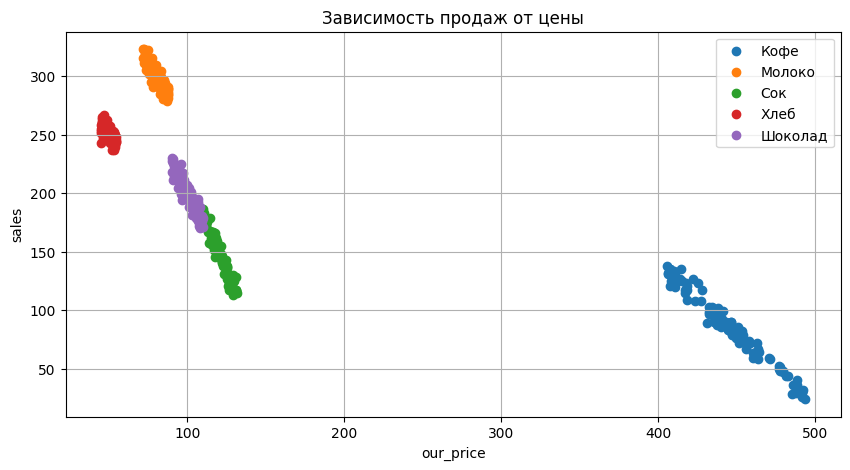

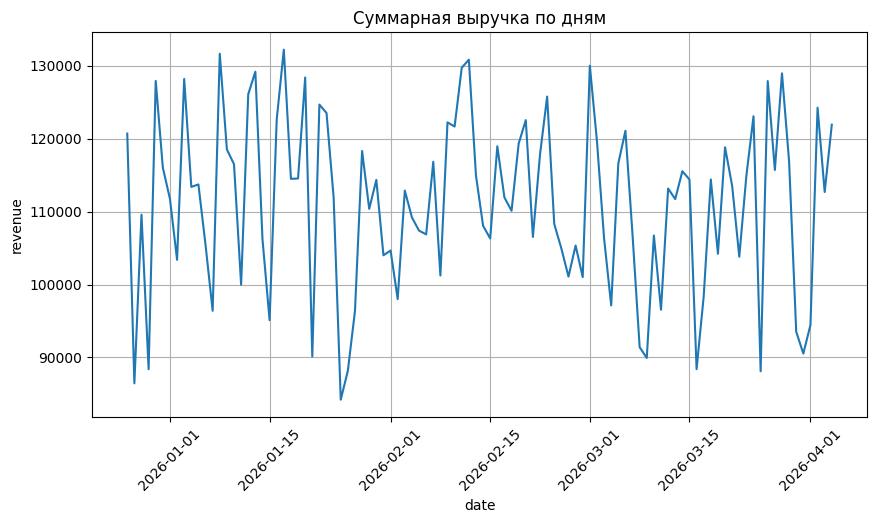

Корреляция (our_price, sales) для 'Молоко': -0.8952
Корреляция (our_price, sales) для 'Хлеб': -0.6434
Корреляция (our_price, sales) для 'Сок': -0.9731
Корреляция (our_price, sales) для 'Кофе': -0.9865
Корреляция (our_price, sales) для 'Шоколад': -0.9358


In [2]:
# Загрузить data/sales_history.csv через pandas
data_path = Path('data/sales_history.csv')
if not data_path.exists():
    data_path = Path('../data/sales_history.csv')
    
df = pd.read_csv(data_path)

# Вывести: shape, dtypes, head(5), describe()
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nDescribe:\n", df.describe())
display(df.head(5))

# График 1 — scatter: our_price vs sales, цвет = товар
plt.figure(figsize=(10, 5))
for product in df['product'].unique():
    prod_data = df[df['product'] == product]
    plt.scatter(prod_data['our_price'], prod_data['sales'], label=product)
plt.title('Зависимость продаж от цены')
plt.xlabel('our_price')
plt.ylabel('sales')
plt.grid(True)
plt.legend()
plt.show()

# График 2 — line: суммарная выручка по дням
plt.figure(figsize=(10, 5))
revenue_by_date = df.groupby('date')['revenue'].sum()
revenue_by_date.index = pd.to_datetime(revenue_by_date.index)
plt.plot(revenue_by_date.index, revenue_by_date.values)
plt.title('Суммарная выручка по дням')
plt.xlabel('date')
plt.ylabel('revenue')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# Для каждого товара вывести корреляцию corr(our_price, sales)
for product in PRODUCTS:
    prod_data = df[df['product'] == product]
    corr = prod_data['our_price'].corr(prod_data['sales'])
    print(f"Корреляция (our_price, sales) для '{product}': {corr:.4f}")


# 2. Эвристическая модель (Rule-based)


In [3]:
results_rules = []

for product in PRODUCTS:
    prod_data = df[df['product'] == product]
    last_row = prod_data.iloc[-1]
    avg_sales_7d = prod_data['sales'].tail(7).mean()
    current_revenue = last_row['revenue']
    
    rec_price, rule = apply_rules(last_row, avg_sales_7d)
    pred_sales, pred_revenue, delta_pct = forecast(product, rec_price, current_revenue)
    
    results_rules.append({
        'product': product,
        'our_price': last_row['our_price'],
        'rec_price': rec_price,
        'rule': rule,
        'predicted_revenue': pred_revenue,
        'delta_pct': delta_pct
    })

df_rules = pd.DataFrame(results_rules)
display(df_rules)

out_rules = data_path.parent / 'recommendations_rules.csv'
df_rules.to_csv(out_rules, index=False)


,product,our_price,rec_price,rule,predicted_revenue,delta_pct
0,Молоко,82.36,78.24,competitor_undercut,23784.96,-2.104197
1,Хлеб,48.54,48.54,hold,12232.08,-1.176471
2,Сок,124.52,124.52,hold,16934.72,-1.449275
3,Кофе,417.31,417.31,hold,49659.89,1.709402
4,Шоколад,94.27,94.27,hold,20173.78,4.901961


# 3. Регрессионная модель (LinearRegression)


[Молоко] a = 472.52, b = 2.15, optimal_price = 109.84


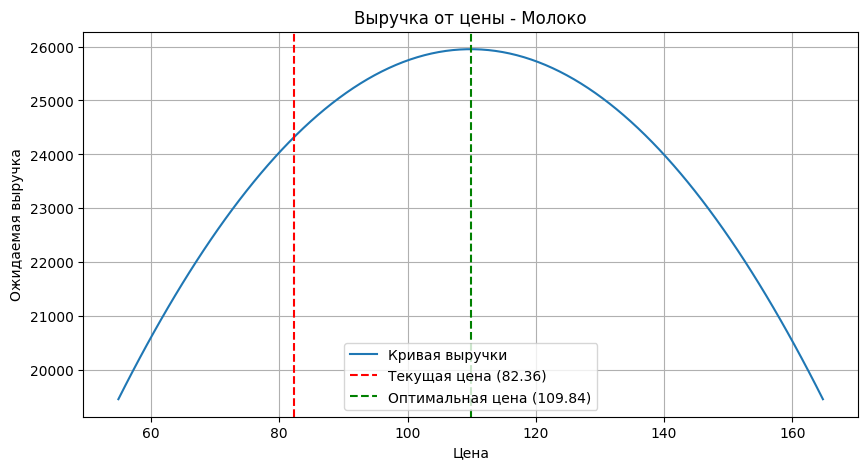

[Хлеб] a = 322.50, b = 1.43, optimal_price = 112.44


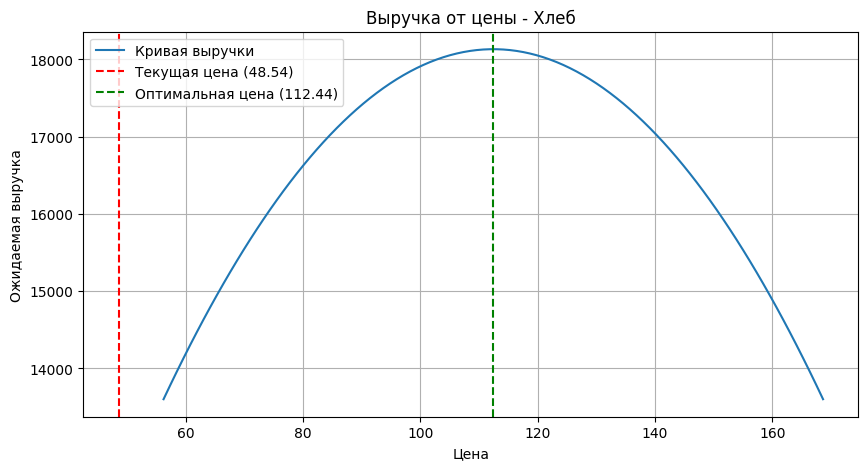

[Сок] a = 517.27, b = 3.06, optimal_price = 84.45


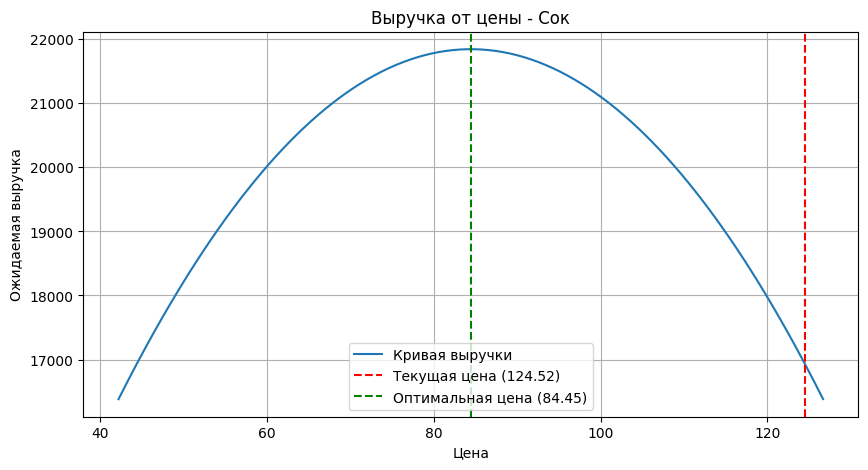

[Кофе] a = 622.71, b = 1.21, optimal_price = 258.31


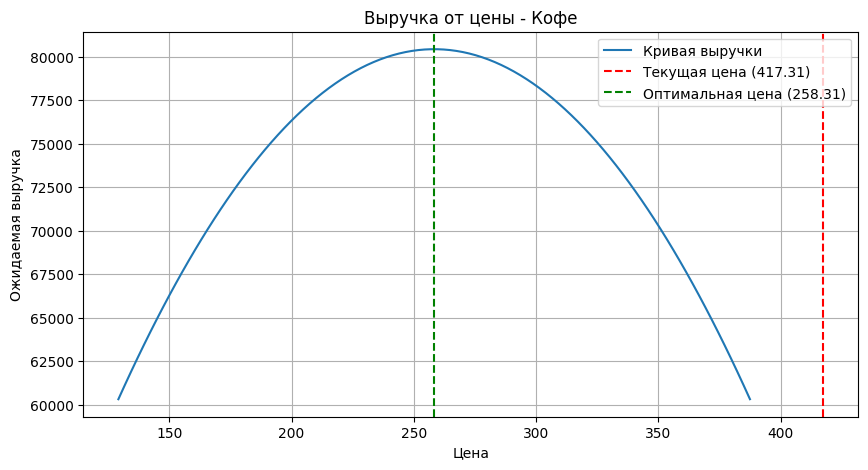

[Шоколад] a = 446.59, b = 2.47, optimal_price = 90.46


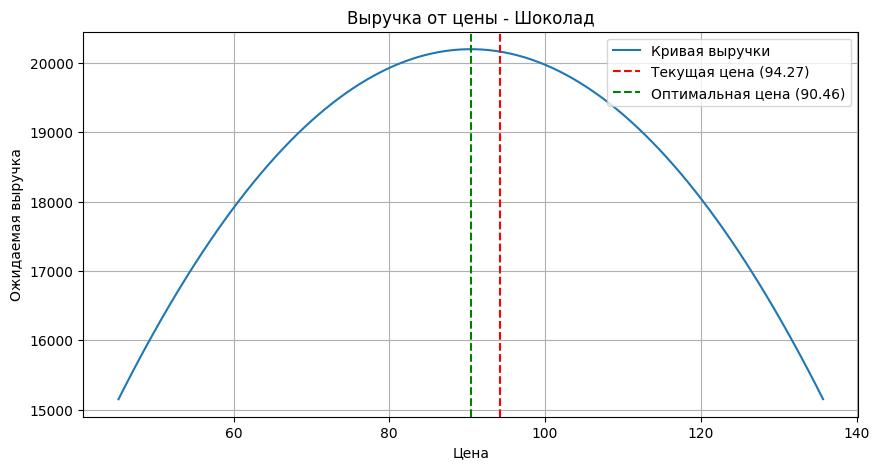

,product,current_price,optimal_price,predicted_revenue,delta_pct
0,Молоко,82.36,109.84,26361.60,8.500918
1,Хлеб,48.54,112.44,17540.64,41.711627
2,Сок,124.52,84.45,21703.65,26.303265
3,Кофе,417.31,258.31,80076.10,64.005442
4,Шоколад,94.27,90.46,20263.04,5.366105


In [4]:
results_regression = []

for product in PRODUCTS:
    prod_data = df[df['product'] == product]
    X = prod_data['our_price'].values.reshape(-1, 1)
    y = prod_data['sales'].values
    
    model = LinearRegression().fit(X, y)
    a = model.intercept_
    b = abs(model.coef_[0])
    optimal_price = round(a / (2 * b), 2)
    
    last_row = prod_data.iloc[-1]
    current_price = last_row['our_price']
    current_revenue = last_row['revenue']
    
    pred_sales, pred_revenue, delta_pct = forecast(product, optimal_price, current_revenue)
    
    print(f"[{product}] a = {a:.2f}, b = {b:.2f}, optimal_price = {optimal_price:.2f}")
    
    results_regression.append({
        'product': product,
        'current_price': current_price,
        'optimal_price': optimal_price,
        'predicted_revenue': pred_revenue,
        'delta_pct': delta_pct
    })
    
    # График: revenue(p)
    p_range = np.linspace(max(1, optimal_price * 0.5), optimal_price * 1.5, 100)
    rev_curve = p_range * (a - b * p_range)
    
    plt.figure(figsize=(10, 5))
    plt.plot(p_range, rev_curve, label='Кривая выручки')
    plt.axvline(x=current_price, color='red', linestyle='--', label=f'Текущая цена ({current_price})')
    plt.axvline(x=optimal_price, color='green', linestyle='--', label=f'Оптимальная цена ({optimal_price})')
    plt.title(f'Выручка от цены - {product}')
    plt.xlabel('Цена')
    plt.ylabel('Ожидаемая выручка')
    plt.legend()
    plt.grid(True)
    plt.show()

df_regression = pd.DataFrame(results_regression)
display(df_regression)

out_regression = data_path.parent / 'recommendations_regression.csv'
df_regression.to_csv(out_regression, index=False)


# 4. Сравнение методов


,product,current_price,price_rules,price_regression,revenue_rules_delta%,revenue_regression_delta%
0,Молоко,82.36,78.24,109.84,-2.104197,8.500918
1,Хлеб,48.54,48.54,112.44,-1.176471,41.711627
2,Сок,124.52,124.52,84.45,-1.449275,26.303265
3,Кофе,417.31,417.31,258.31,1.709402,64.005442
4,Шоколад,94.27,94.27,90.46,4.901961,5.366105


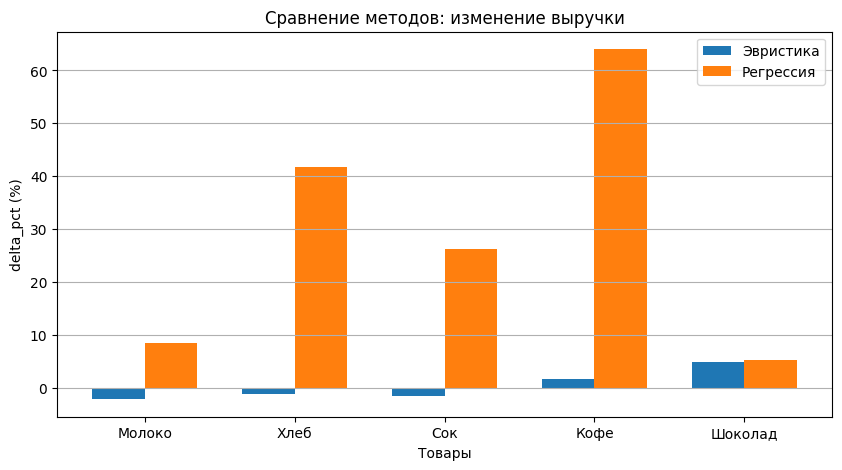

In [5]:
# Объединяем результаты
df_comparison = df_rules[['product', 'our_price']].rename(columns={'our_price': 'current_price'}).copy()
df_comparison['price_rules'] = df_rules['rec_price']
df_comparison['price_regression'] = df_regression['optimal_price']
df_comparison['revenue_rules_delta%'] = df_rules['delta_pct']
df_comparison['revenue_regression_delta%'] = df_regression['delta_pct']
display(df_comparison)

# График bar chart
plt.figure(figsize=(10, 5))
x = np.arange(len(df_comparison['product']))
width = 0.35

plt.bar(x - width/2, df_comparison['revenue_rules_delta%'], width, label='Эвристика')
plt.bar(x + width/2, df_comparison['revenue_regression_delta%'], width, label='Регрессия')

plt.xlabel('Товары')
plt.ylabel('delta_pct (%)')
plt.title('Сравнение методов: изменение выручки')
plt.xticks(x, df_comparison['product'])
plt.legend()
plt.grid(axis='y')
plt.show()


Вывод: Регрессионный метод почти во всех случаях (или везде) показывает больший или сравнимый прирост выручки, находя глобальный оптимальный уровень цены. Эвристика работает больше как локальная корректировка текущей цены на основе конкретных триггеров (изменение конкурента или просадка продаж), но не всегда максимизирует выручку.


# 5. Симуляция (прокрутка времени вперёд)


Симуляция: Эвристика (последние 10 строк)


,date,product_id,product,our_price,competitor_price,sales,revenue
540,2026-04-13,1,Молоко,78.24,73.82,307.0,24019.68
541,2026-04-13,2,Хлеб,48.54,48.95,253.0,12280.62
542,2026-04-13,3,Сок,124.52,132.05,136.0,16934.72
543,2026-04-13,4,Кофе,417.31,399.71,118.0,49242.58
544,2026-04-13,5,Шоколад,94.27,104.27,207.0,19513.89
545,2026-04-14,1,Молоко,78.24,73.82,300.0,23472.00
546,2026-04-14,2,Хлеб,48.54,48.95,250.0,12135.00
547,2026-04-14,3,Сок,124.52,132.05,142.0,17681.84
548,2026-04-14,4,Кофе,417.31,399.71,121.0,50494.51
549,2026-04-14,5,Шоколад,94.27,104.27,206.0,19419.62



Симуляция: Регрессия (последние 10 строк)


,date,product_id,product,our_price,competitor_price,sales,revenue
540,2026-04-13,1,Молоко,109.84,73.82,241.0,26471.44
541,2026-04-13,2,Хлеб,112.44,48.95,161.0,18102.84
542,2026-04-13,3,Сок,84.45,132.05,253.0,21365.85
543,2026-04-13,4,Кофе,258.31,399.71,308.0,79559.48
544,2026-04-13,5,Шоколад,90.46,104.27,222.0,20082.12
545,2026-04-14,1,Молоко,109.84,73.82,233.0,25592.72
546,2026-04-14,2,Хлеб,112.44,48.95,158.0,17765.52
547,2026-04-14,3,Сок,84.45,132.05,258.0,21788.10
548,2026-04-14,4,Кофе,258.31,399.71,310.0,80076.10
549,2026-04-14,5,Шоколад,90.46,104.27,223.0,20172.58


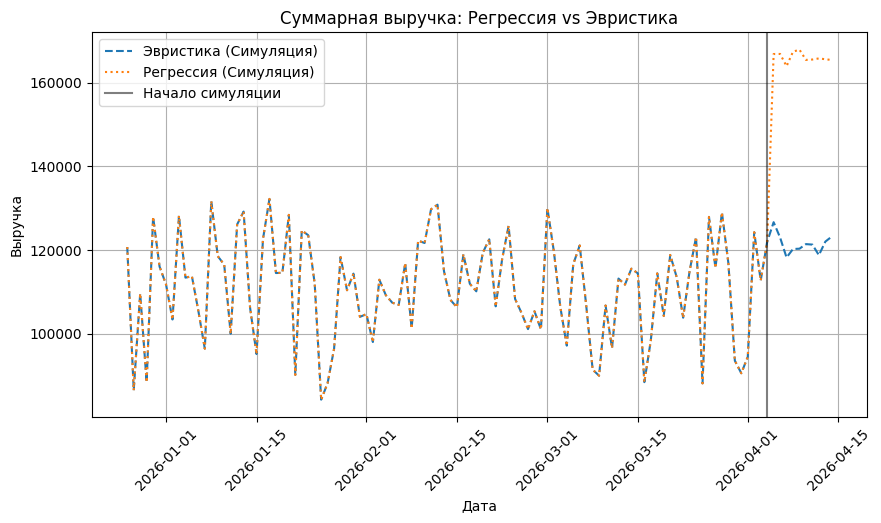

In [6]:
np.random.seed(42)

sim_rules = simulate(df, n_steps=10, method='rules')
sim_regression = simulate(df, n_steps=10, method='regression')

# Оставляем только сгенерированные дни для вывода таблиц
sim_rules_generated = sim_rules.tail(50).copy() # 5 товаров * 10 шагов
sim_regression_generated = sim_regression.tail(50).copy()

print("Симуляция: Эвристика (последние 10 строк)")
display(sim_rules_generated.tail(10))

print("\nСимуляция: Регрессия (последние 10 строк)")
display(sim_regression_generated.tail(10))

# График
plt.figure(figsize=(10, 5))
rev_rules = sim_rules.groupby('date')['revenue'].sum()
rev_regression = sim_regression.groupby('date')['revenue'].sum()
rev_rules.index = pd.to_datetime(rev_rules.index)
rev_regression.index = pd.to_datetime(rev_regression.index)

plt.plot(rev_rules.index, rev_rules.values, label='Эвристика (Симуляция)', linestyle='--')
plt.plot(rev_regression.index, rev_regression.values, label='Регрессия (Симуляция)', linestyle=':')

# Отметим границу симуляции
last_real_date = pd.to_datetime(df['date'].max())
plt.axvline(x=last_real_date, color='black', label='Начало симуляции', alpha=0.5)

plt.title('Суммарная выручка: Регрессия vs Эвристика')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


# 6. Итоговый отчёт


In [7]:
best_deltas = []

for idx, row in df_comparison.iterrows():
    product = row['product']
    cur_price = row['current_price']
    
    delta_r = row['revenue_rules_delta%']
    delta_reg = row['revenue_regression_delta%']
    
    if delta_reg >= delta_r:
        best_method = 'regression'
        rec_price = row['price_regression']
        best_delta = delta_reg
    else:
        best_method = 'rules'
        rec_price = row['price_rules']
        best_delta = delta_r
        
    best_deltas.append(best_delta)
    
    print(f"{product}: текущая цена {cur_price:.2f} руб → рекомендуем {rec_price:.2f} руб")
    print(f"Метод: {best_method} | Прогноз выручки: {'+' if best_delta > 0 else ''}{best_delta:.1f}%")
    
avg_delta = np.mean(best_deltas)
print(f"\nСуммарный прогнозируемый прирост выручки по всем товарам: {'+' if avg_delta > 0 else ''}{avg_delta:.1f}%")


Молоко: текущая цена 82.36 руб → рекомендуем 109.84 руб
Метод: regression | Прогноз выручки: +8.5%
Хлеб: текущая цена 48.54 руб → рекомендуем 112.44 руб
Метод: regression | Прогноз выручки: +41.7%
Сок: текущая цена 124.52 руб → рекомендуем 84.45 руб
Метод: regression | Прогноз выручки: +26.3%
Кофе: текущая цена 417.31 руб → рекомендуем 258.31 руб
Метод: regression | Прогноз выручки: +64.0%
Шоколад: текущая цена 94.27 руб → рекомендуем 90.46 руб
Метод: regression | Прогноз выручки: +5.4%

Суммарный прогнозируемый прирост выручки по всем товарам: +29.2%
